# 1.Installation Packages and Libraries

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import shapiro

#2. Forest Data Creation using ucimlrepo

In [4]:
from data_loader import load_data
df = load_data()
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


**Description of the attributes**:
   1. X - x-axis spatial coordinate within the Montesinho park map: 1 to 9
   2. Y - y-axis spatial coordinate within the Montesinho park map: 2 to 9
   3. month - month of the year: 'jan' to 'dec'
   4. day - day of the week: 'mon' to 'sun'
   5. FFMC - FFMC index from the FWI system: 18.7 to 96.20
   6. DMC - DMC index from the FWI system: 1.1 to 291.3
   7. DC - DC index from the FWI system: 7.9 to 860.6
   8. ISI - ISI index from the FWI system: 0.0 to 56.10
   9. temp - temperature in Celsius degrees: 2.2 to 33.30
   10. RH - relative humidity in %: 15 to 100
   11. wind - wind speed in km/h: 0.40 to 9.40
   12. rain - outside rain in mm/m2 : 0.0 to 6.4
   13. area - the burned area of the forest (in ha): 0.00 to 1090.84

#3.EDA

## Initial Data Inspection


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
 12  area    517 non-null    float64
dtypes: float64(8), int64(3), object(2)
memory usage: 52.6+ KB


We have 3 target values (int64) for coordinates and RH, 2 object columns for categorical values, and 8 float values


In [6]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


According to the describe method

In [7]:
df.shape
df[df.duplicated()]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
53,4,3,aug,wed,92.1,111.2,654.1,9.6,20.4,42,4.9,0.0,0.00
100,3,4,aug,sun,91.4,142.4,601.4,10.6,19.8,39,5.4,0.0,0.00
215,4,4,mar,sat,91.7,35.8,80.8,7.8,17.0,27,4.9,0.0,28.66
303,3,6,jun,fri,91.1,94.1,232.1,7.1,19.2,38,4.5,0.0,0.00


In [8]:
df.drop_duplicates(inplace = True)
df.shape

(513, 13)

In [9]:
df[df.isnull().any(axis = 1)]

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area


In [10]:
df.columns = df.columns.str.lower()
df.columns

Index(['x', 'y', 'month', 'day', 'ffmc', 'dmc', 'dc', 'isi', 'temp', 'rh',
       'wind', 'rain', 'area'],
      dtype='object')

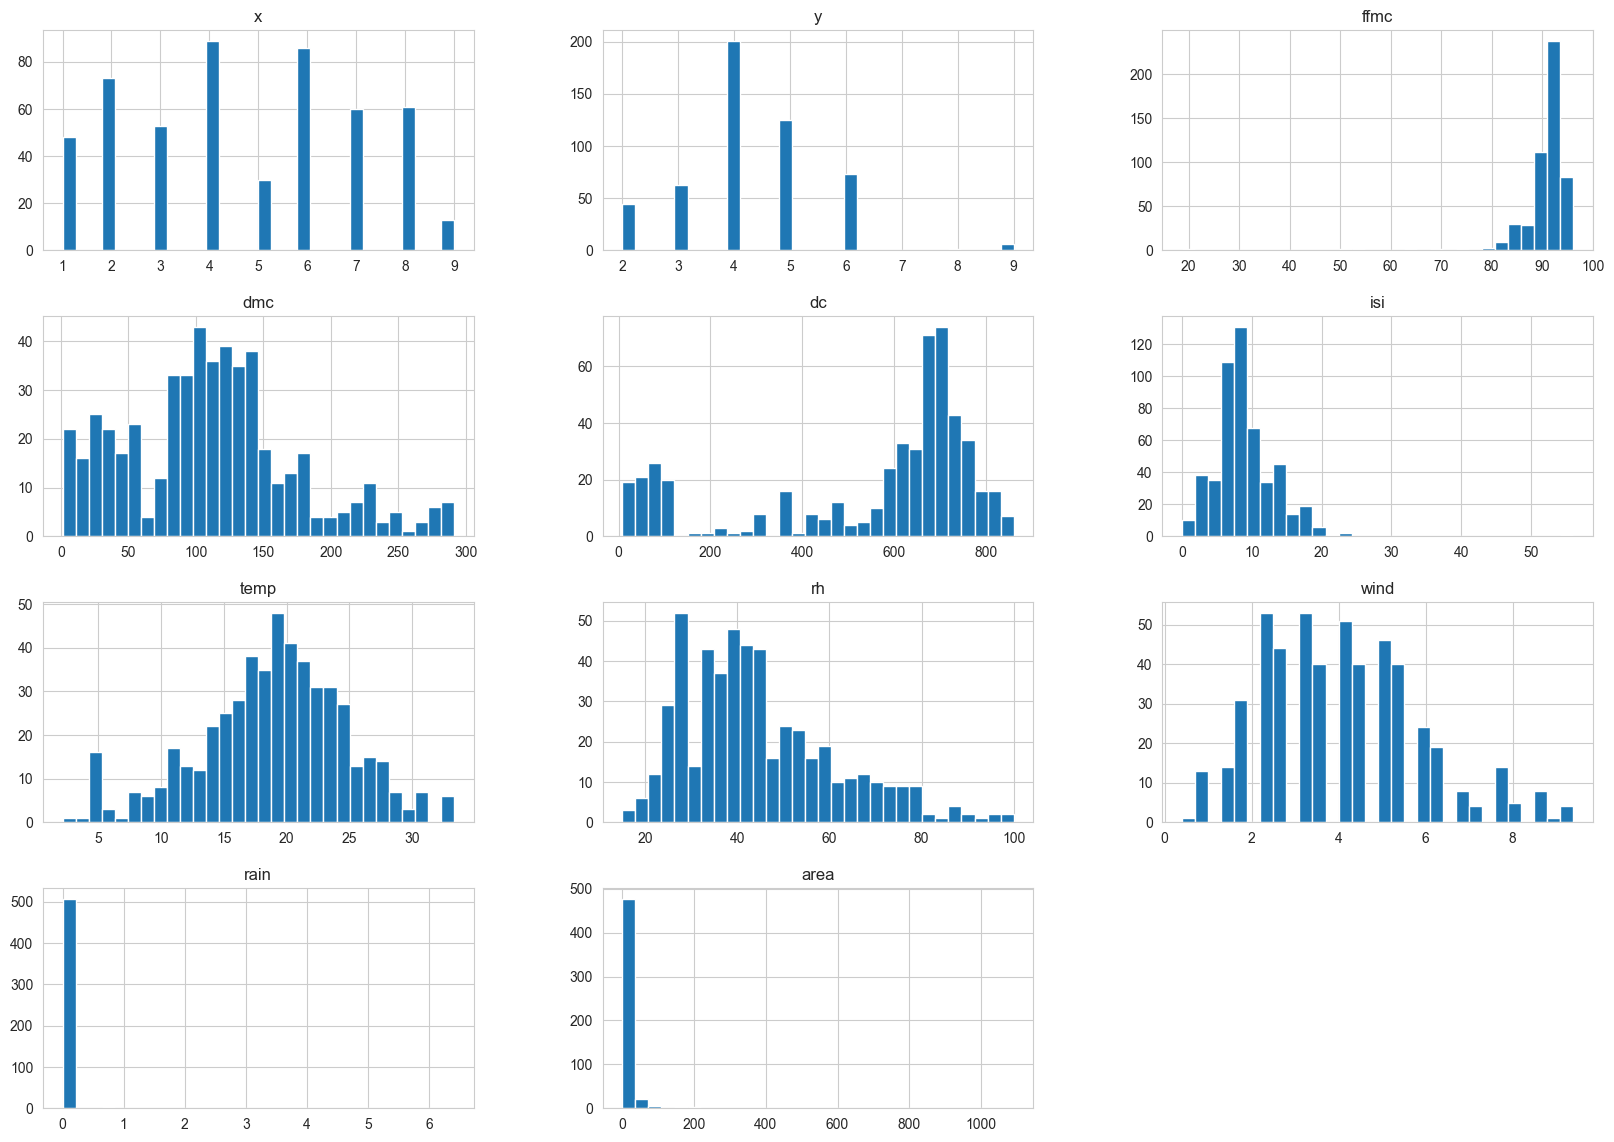

In [11]:
sns.set_style("whitegrid")
df.hist(bins = 30, figsize = (20, 14))
plt.show()

In [12]:
stat, p_value = shapiro(df["temp"])
print(f"Statistic: {stat}, p-value: {p_value}")
if p_value > 0.05:
  print("Temperature destribution is normal")
else:
  print("Temperature destribution is not normal")

Statistic: 0.9870314826271165, p-value: 0.0001586649123650395
Temperature destribution is not normal


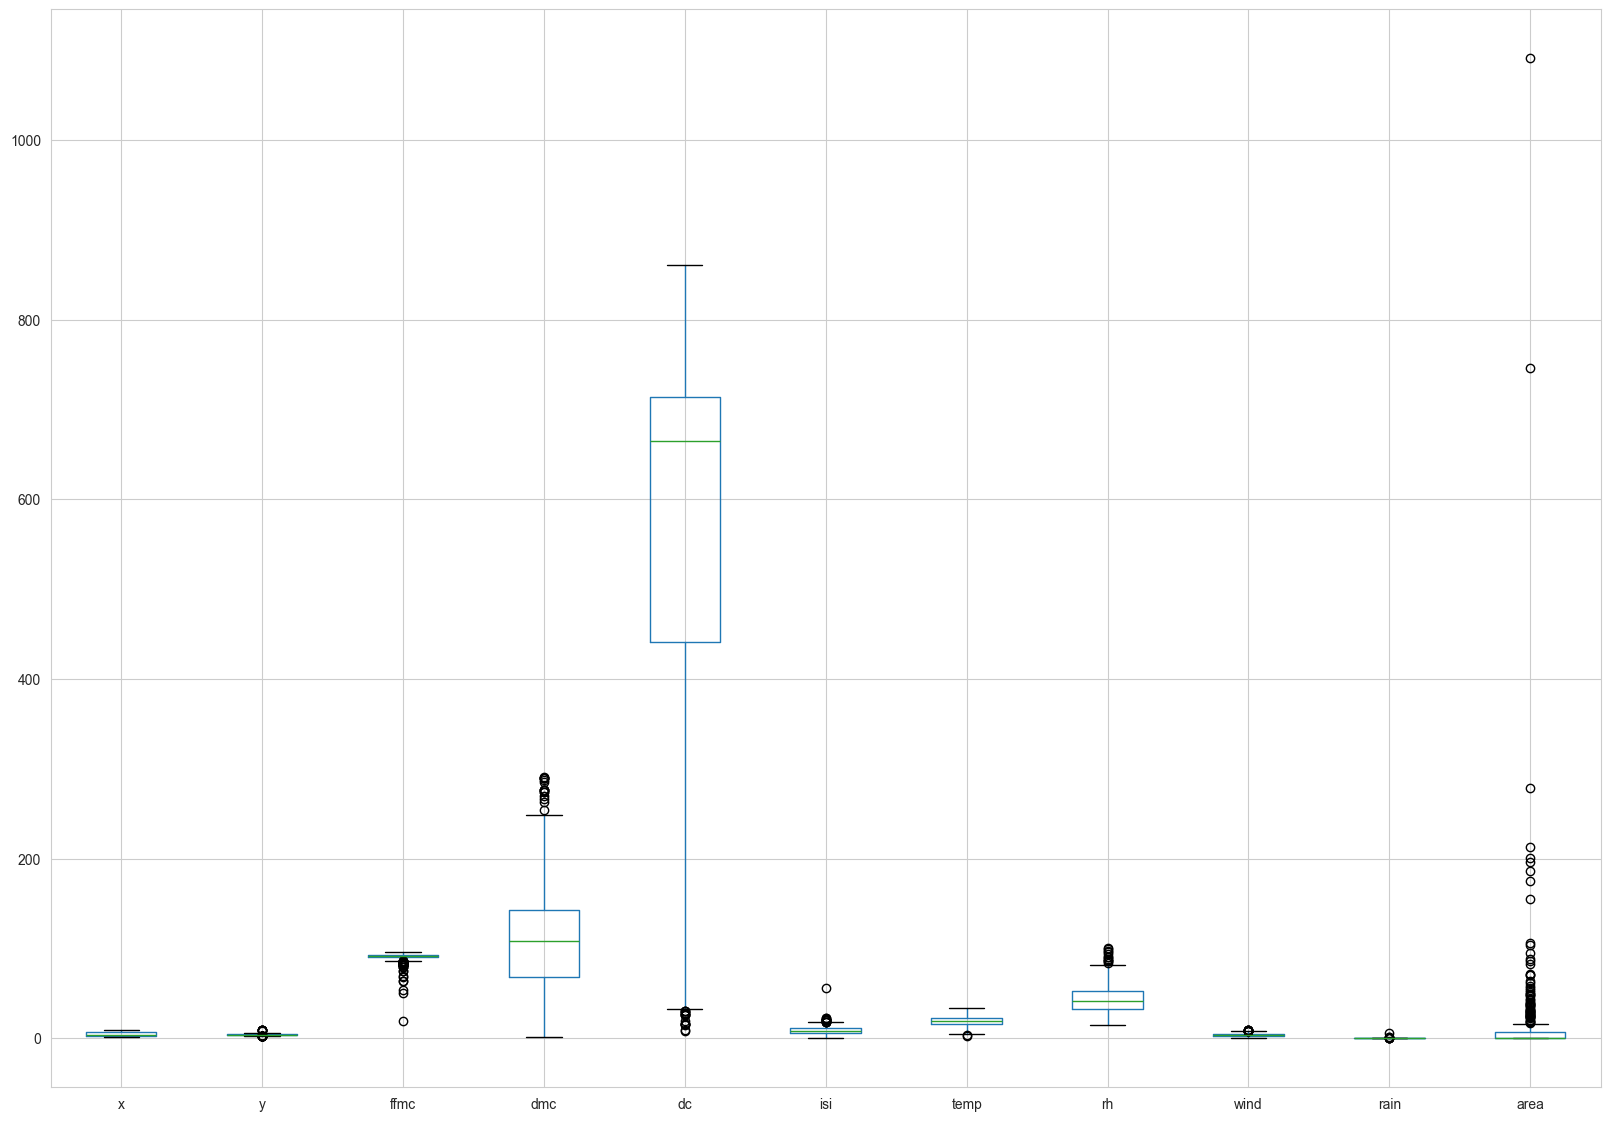

In [13]:
df.boxplot(figsize  = (20, 14))
plt.show()

In [14]:
pivot_temp = df.pivot_table(
    values="temp",
    index="month",
    columns="day",
    aggfunc="mean"
)

pivot_temp


day,fri,mon,sat,sun,thu,tue,wed
month,,,,,,,
apr,16.700000,10.900000,9.300000,14.900000,5.800000,NaN,15.200000
aug,21.238095,22.693333,20.503448,21.294872,21.407692,21.842857,23.345833
dec,2.200000,4.600000,NaN,4.800000,5.100000,5.100000,5.100000
feb,11.680000,8.900000,11.725000,8.875000,6.700000,4.850000,8.800000
jan,NaN,NaN,5.300000,5.200000,NaN,NaN,NaN
jul,17.033333,21.575000,22.450000,24.360000,29.200000,22.500000,15.366667
jun,21.200000,18.033333,17.550000,18.225000,24.550000,NaN,25.200000
mar,14.000000,11.783333,15.255556,10.628571,11.420000,15.100000,12.450000
may,18.000000,NaN,11.300000,NaN,NaN,NaN,NaN


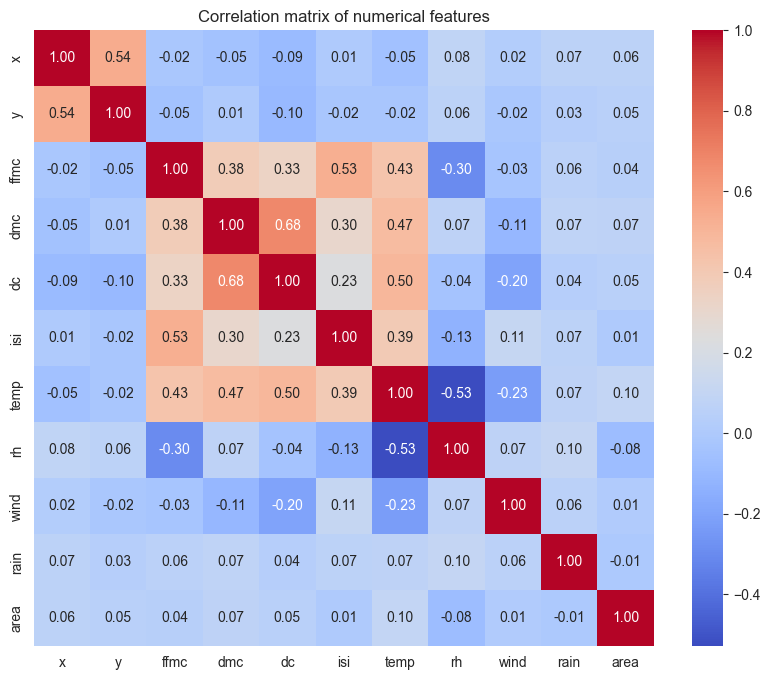

In [15]:
numeric_df = df.select_dtypes(include="number")
plt.figure(figsize=(10,8))
sns.heatmap(
    numeric_df.corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Correlation matrix of numerical features")
plt.show()

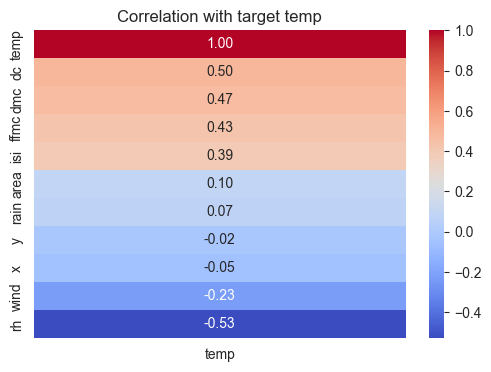

In [16]:
plt.figure(figsize=(6,4))
temp_corr = numeric_df.corr()["temp"].sort_values(ascending=False)
sns.heatmap(
    temp_corr.to_frame(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm")

plt.title("Correlation with target temp")
plt.show()

In [17]:
def correlation(dataset, threshold):
  corr_set = set()
  corr_matrix = dataset.corr()
  for i in range(len(corr_matrix.columns)):
    for j in range(i):
      if abs(corr_matrix.iloc[i, j]) > threshold:
        colname = corr_matrix.columns[i]
        corr_set.add(colname)
  return corr_set


correlation(numeric_df, 0.7)

set()

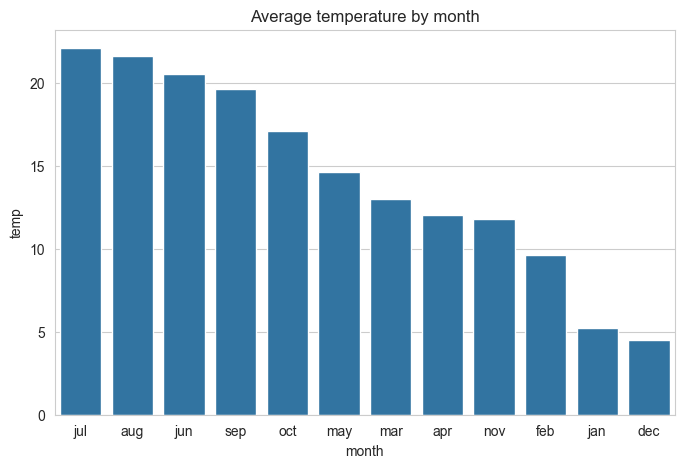

In [18]:
month_order = df.groupby("month")["temp"].mean().sort_values(ascending =False).reset_index()

plt.figure(figsize=(8,5))
sns.barplot(
    data=month_order,
    x="month",
    y="temp",
    estimator="mean",
    errorbar=None
)

plt.title("Average temperature by month")
plt.show()

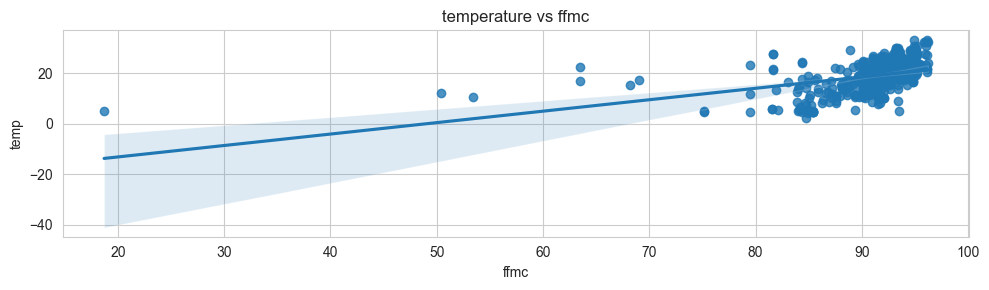

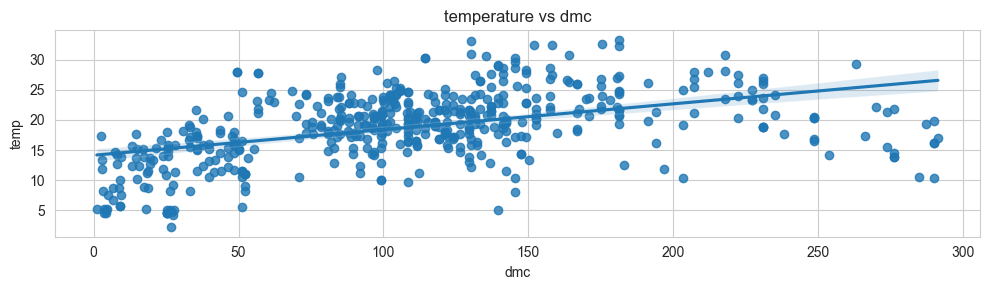

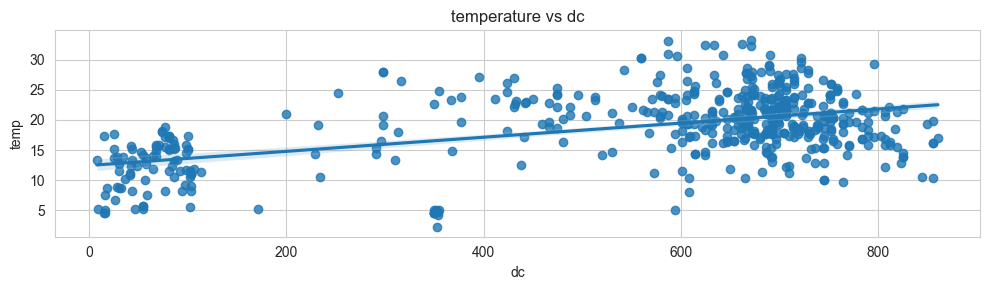

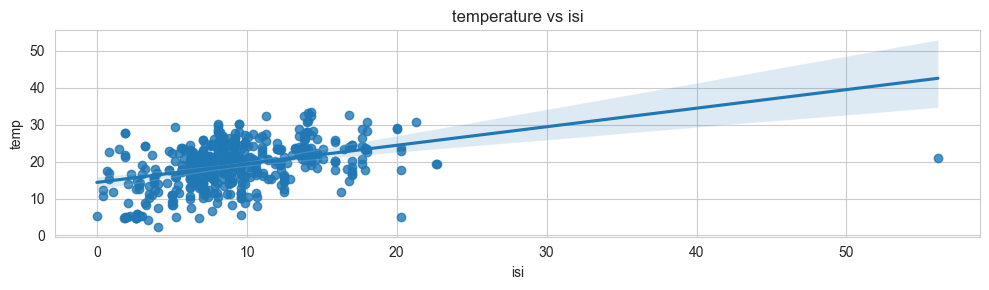

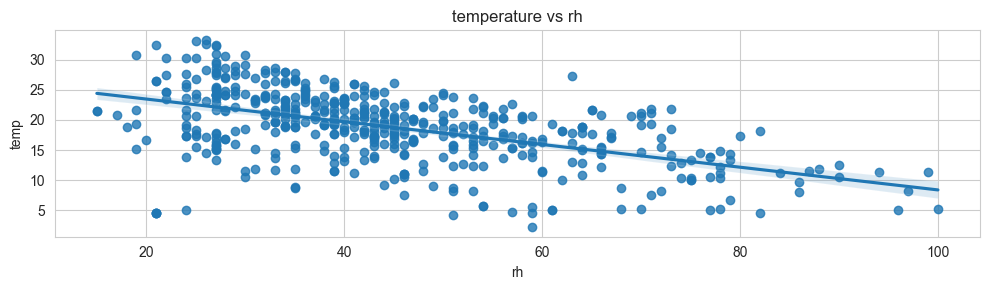

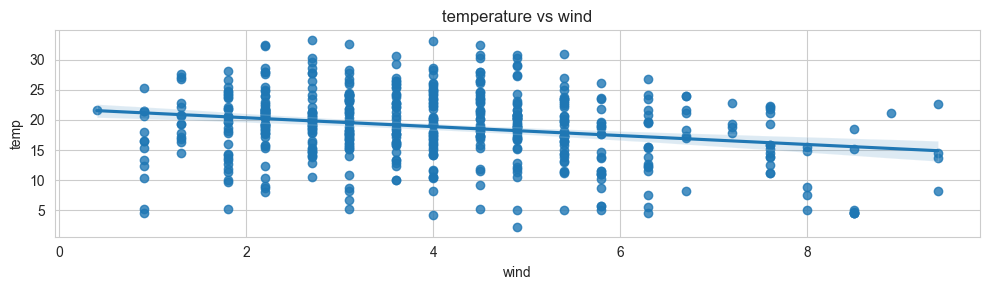

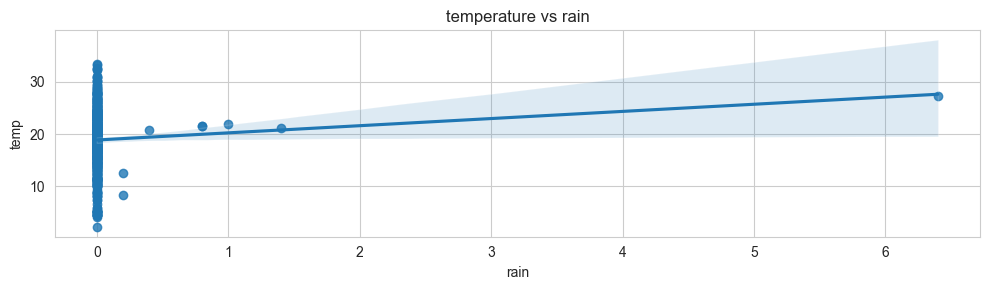

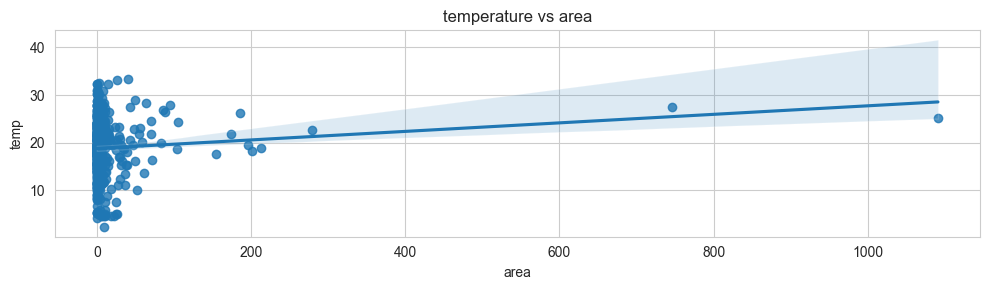

In [19]:
features = ['ffmc', 'dmc', 'dc', 'isi', 'rh', 'wind', 'rain', 'area']

for feature in features:
  plt.figure(figsize=(10,3))
  sns.regplot(
    data=df,
    x=feature,
    y="temp"
  )

  plt.title(f"temperature vs {feature}")
  plt.tight_layout()
  plt.show()

In [20]:
df.to_pickle("processed_forest_fires.pkl")